In [1]:
import numpy as np
import time
import pandas as pd
from scipy import stats
import warnings
from bezierv.classes.distfit import DistFit
from tqdm import tqdm

In [2]:
def test_bezierv_fit_distributions(m: int, n: int = 5, n_trials: int = 100, output_file: str = 'benchmark_results.csv'):
    """
    Benchmarks bezierv fits against standard statistical distributions over multiple trials.
    Includes a percentage progress bar.
    """
    
    warnings.filterwarnings("ignore")
    
    # --- Helper: Negative Log Likelihood Calculation ---
    def calc_neg_log_lik(logpdf_func, data, params=None):
        try:
            if params:
                logpdf = logpdf_func(data, *params)
            else:
                logpdf = logpdf_func(data)
            logpdf = np.asarray(logpdf)
            if np.any(~np.isfinite(logpdf)):
                return np.nan
            return -np.sum(logpdf)
        except Exception:
            return np.nan

    # --- Helper: MSE with Empirical CDF ---
    def calc_mse_empirical_cdf(cdf_func, data, params=None):
        try:
            # Sort data for empirical CDF
            sorted_data = np.sort(data)
            empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            
            # Evaluate theoretical CDF at sorted data points
            if params:
                if isinstance(params, tuple):
                    theoretical_cdf = cdf_func(sorted_data, *params)
                else:
                    theoretical_cdf = cdf_func(sorted_data, **params)
            else:
                theoretical_cdf = cdf_func(sorted_data)
            
            theoretical_cdf = np.asarray(theoretical_cdf)
            
            if np.any(~np.isfinite(theoretical_cdf)):
                return np.nan
            
            # Calculate MSE
            mse = np.mean((empirical_cdf - theoretical_cdf) ** 2)
            return mse
        except Exception:
            return np.nan

    # --- Helper: MSE for Bezierv (cdf_x doesn't support arrays) ---
    def calc_mse_bezierv(bezierv_obj, data):
        try:
            # Sort data for empirical CDF
            sorted_data = np.sort(data)
            empirical_cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
            
            # Evaluate theoretical CDF at sorted data points using cdf_x for each point
            theoretical_cdf = np.array([bezierv_obj.cdf_x(x) for x in sorted_data])
            
            if np.any(~np.isfinite(theoretical_cdf)):
                return np.nan
            
            # Calculate MSE
            mse = np.mean((empirical_cdf - theoretical_cdf) ** 2)
            return mse
        except Exception:
            return np.nan

    dist_names = [
        'gamma', 'normal', 'exponential', 'lognormal', 'chi_square',
        'rayleigh', 'weibull', 'logistic', 'gumbel', 'laplace', 'trimodal'
    ]
    
    param_ranges = {
        'gamma': lambda: {'a': np.random.uniform(0.5, 5), 'scale': np.random.uniform(0.5, 3)},
        'normal': lambda: {'loc': np.random.uniform(-5, 5), 'scale': np.random.uniform(0.5, 3)},
        'expo': lambda: {'scale': np.random.uniform(0.5, 3)},
        'lognorm': lambda: {'s': np.random.uniform(0.1, 1.5), 'scale': np.random.uniform(0.5, 3)},
        'chi2': lambda: {'df': np.random.randint(1, 11)},
        'rayleigh': lambda: {'scale': np.random.uniform(0.5, 3)},
        'weibull': lambda: {'c': np.random.uniform(0.5, 3), 'scale': np.random.uniform(0.5, 3)},
        'logistic': lambda: {'loc': np.random.uniform(-5, 5), 'scale': np.random.uniform(0.5, 3)},
        'gumbel': lambda: {'loc': np.random.uniform(-5, 5), 'scale': np.random.uniform(0.5, 3)},
        'laplace': lambda: {'loc': np.random.uniform(-5, 5), 'scale': np.random.uniform(0.5, 3)},
        'trimodal': lambda: {
            'loc1': np.random.uniform(-5, -1), 'loc2': np.random.uniform(-1, 1), 
            'loc3': np.random.uniform(1, 5), 'scale': np.random.uniform(0.3, 1.0)
        }
    }

    print(f"Starting Benchmark: {n_trials} trials per distribution, {m} samples each.")
    print(f"Comparing Bezier(n={n}) vs Beta, Pearson, Johnson, GenGamma.")
    print("=" * 80)

    all_results = []
    start_total = time.time()
    
    total_iterations = n_trials * len(dist_names)
    pbar = tqdm(total=total_iterations, desc="Benchmarking", unit="fit")
    counter = 0

    for trial in range(1, n_trials + 1):
        
        current_params = {k: v() for k, v in param_ranges.items()}

        for name in dist_names:
            
            if name == 'trimodal':
                p = current_params['trimodal']
                data = np.concatenate([
                    np.random.normal(loc=p['loc1'], scale=p['scale'], size=m//3),
                    np.random.normal(loc=p['loc2'], scale=p['scale'], size=m//3),
                    np.random.normal(loc=p['loc3'], scale=p['scale'], size=m - 2*(m//3))
                ])
            else:
                mapping = {
                    'gamma': (stats.gamma, {'a': current_params['gamma']['a'], 'scale': current_params['gamma']['scale']}),
                    'normal': (stats.norm, {'loc': current_params['normal']['loc'], 'scale': current_params['normal']['scale']}),
                    'exponential': (stats.expon, {'scale': current_params['expo']['scale']}),
                    'lognormal': (stats.lognorm, {'s': current_params['lognorm']['s'], 'scale': current_params['lognorm']['scale']}),
                    'chi_square': (stats.chi2, {'df': current_params['chi2']['df']}),
                    'rayleigh': (stats.rayleigh, {'scale': current_params['rayleigh']['scale']}),
                    'weibull': (stats.weibull_min, {'c': current_params['weibull']['c'], 'scale': current_params['weibull']['scale']}),
                    'logistic': (stats.logistic, {'loc': current_params['logistic']['loc'], 'scale': current_params['logistic']['scale']}),
                    'gumbel': (stats.gumbel_r, {'loc': current_params['gumbel']['loc'], 'scale': current_params['gumbel']['scale']}),
                    'laplace': (stats.laplace, {'loc': current_params['laplace']['loc'], 'scale': current_params['laplace']['scale']}),
                }
                func, args = mapping[name]
                data = func.rvs(**args, size=m)

            # --- A. Bezier Fits ---
            methods = [('Bez_MLE', 'mle')]
            for method_label, method_key in methods:
                t_start = time.time()
                neg_log_lik = np.nan
                mse = np.nan
                try:
                    distfit = DistFit(data=data, n=n)
                    bezierv, neg_log_lik = distfit.fit(method='mle')
                    # Calculate MSE for Bezier fit using the special bezierv helper
                    mse = calc_mse_bezierv(bezierv, data)
                except: pass
                all_results.append({'Trial': trial, 'Dist': name, 'Method': method_label, 'Time': time.time() - t_start, 'NegLogLik': neg_log_lik, 'MSE': mse})

            # --- B. Benchmarks ---
            
            # Generalized Beta
            t_start = time.time()
            neg_log_lik = np.nan
            mse = np.nan
            try:
                p_beta = stats.beta.fit(data)
                neg_log_lik = calc_neg_log_lik(stats.beta.logpdf, data, p_beta)
                mse = calc_mse_empirical_cdf(stats.beta.cdf, data, p_beta)
            except: pass
            all_results.append({'Trial': trial, 'Dist': name, 'Method': 'Gen_Beta', 'Time': time.time() - t_start, 'NegLogLik': neg_log_lik, 'MSE': mse})

            # Pearson III
            t_start = time.time()
            neg_log_lik = np.nan
            mse = np.nan
            try:
                p_p3 = stats.pearson3.fit(data)
                neg_log_lik = calc_neg_log_lik(stats.pearson3.logpdf, data, p_p3)
                mse = calc_mse_empirical_cdf(stats.pearson3.cdf, data, p_p3)
            except: pass
            all_results.append({'Trial': trial, 'Dist': name, 'Method': 'Pearson3', 'Time': time.time() - t_start, 'NegLogLik': neg_log_lik, 'MSE': mse})

            # Johnson
            t_start = time.time()
            neg_log_lik = np.nan
            mse = np.nan
            try:
                p_sb = stats.johnsonsb.fit(data)
                nll_sb = calc_neg_log_lik(stats.johnsonsb.logpdf, data, p_sb)
                mse_sb = calc_mse_empirical_cdf(stats.johnsonsb.cdf, data, p_sb)
                p_su = stats.johnsonsu.fit(data)
                nll_su = calc_neg_log_lik(stats.johnsonsu.logpdf, data, p_su)
                mse_su = calc_mse_empirical_cdf(stats.johnsonsu.cdf, data, p_su)
                
                neg_log_lik = min(nll_sb if not np.isnan(nll_sb) else np.inf, nll_su if not np.isnan(nll_su) else np.inf)
                if neg_log_lik == np.inf: neg_log_lik = np.nan
                
                mse = min(mse_sb if not np.isnan(mse_sb) else np.inf, mse_su if not np.isnan(mse_su) else np.inf)
                if mse == np.inf: mse = np.nan
            except: pass
            all_results.append({'Trial': trial, 'Dist': name, 'Method': 'Johnson', 'Time': time.time() - t_start, 'NegLogLik': neg_log_lik, 'MSE': mse})

            # 4-Param
            t_start = time.time()
            neg_log_lik = np.nan
            mse = np.nan
            try:
                p_gg = stats.gengamma.fit(data)
                neg_log_lik = calc_neg_log_lik(stats.gengamma.logpdf, data, p_gg)
                mse = calc_mse_empirical_cdf(stats.gengamma.cdf, data, p_gg)
            except: pass
            all_results.append({'Trial': trial, 'Dist': name, 'Method': '4Param_GG', 'Time': time.time() - t_start, 'NegLogLik': neg_log_lik, 'MSE': mse})

        
            counter += 1
            pbar.update(1)
           

    
    pbar.close()

    print("\nProcessing Results...")
    df = pd.DataFrame(all_results)
    df.to_csv(output_file, index=False)
    
    summary = df.groupby(['Dist', 'Method']).agg({
        'NegLogLik': ['mean'],
        'MSE': ['mean'],
        'Time': ['mean']
    }).reset_index()
    summary.columns = ['Dist', 'Method', 'Mean_NegLogLik', 'Mean_MSE', 'Mean_Time']
    
    print("\nSummary of Average Performance (Lower NegLogLik and MSE are better):")
    print("-" * 130)
    print(f"{'Distribution':<15} | {'Method':<15} | {'Mean NegLogLik':<15} | {'Mean MSE':<15} | {'Time (s)':<8}")
    print("-" * 130)
    
    summary = summary.sort_values(by=['Dist', 'Mean_NegLogLik'])
    for _, row in summary.iterrows():
        print(f"{row['Dist']:<15} | {row['Method']:<15} | {row['Mean_NegLogLik']:15.6e} | {row['Mean_MSE']:15.6e} | {row['Mean_Time']:8.4f}")

    return summary


In [3]:
summary = test_bezierv_fit_distributions(m=1000, n=10, n_trials=10, output_file='benchmark_results.csv')

Starting Benchmark: 10 trials per distribution, 1000 samples each.
Comparing Bezier(n=10) vs Beta, Pearson, Johnson, GenGamma.


Benchmarking: 100%|██████████| 110/110 [01:10<00:00,  1.56fit/s]


Processing Results...

Summary of Average Performance (Lower NegLogLik and MSE are better):
----------------------------------------------------------------------------------------------------------------------------------
Distribution    | Method          | Mean NegLogLik  | Mean MSE        | Time (s)
----------------------------------------------------------------------------------------------------------------------------------
chi_square      | Bez_MLE         |    2.225062e+03 |    3.013475e-05 |   0.3818
chi_square      | 4Param_GG       |    2.617373e+03 |    5.316145e-05 |   0.0736
chi_square      | Pearson3        |    2.617722e+03 |    5.780357e-05 |   0.0221
chi_square      | Gen_Beta        |    2.618694e+03 |    7.425463e-05 |   0.0487
chi_square      | Johnson         |    2.618705e+03 |    5.873996e-05 |   0.1316
exponential     | 4Param_GG       |    1.571272e+03 |    8.989643e-05 |   0.1116
exponential     | Gen_Beta        |    1.571976e+03 |    9.422488e-05 |   0.06

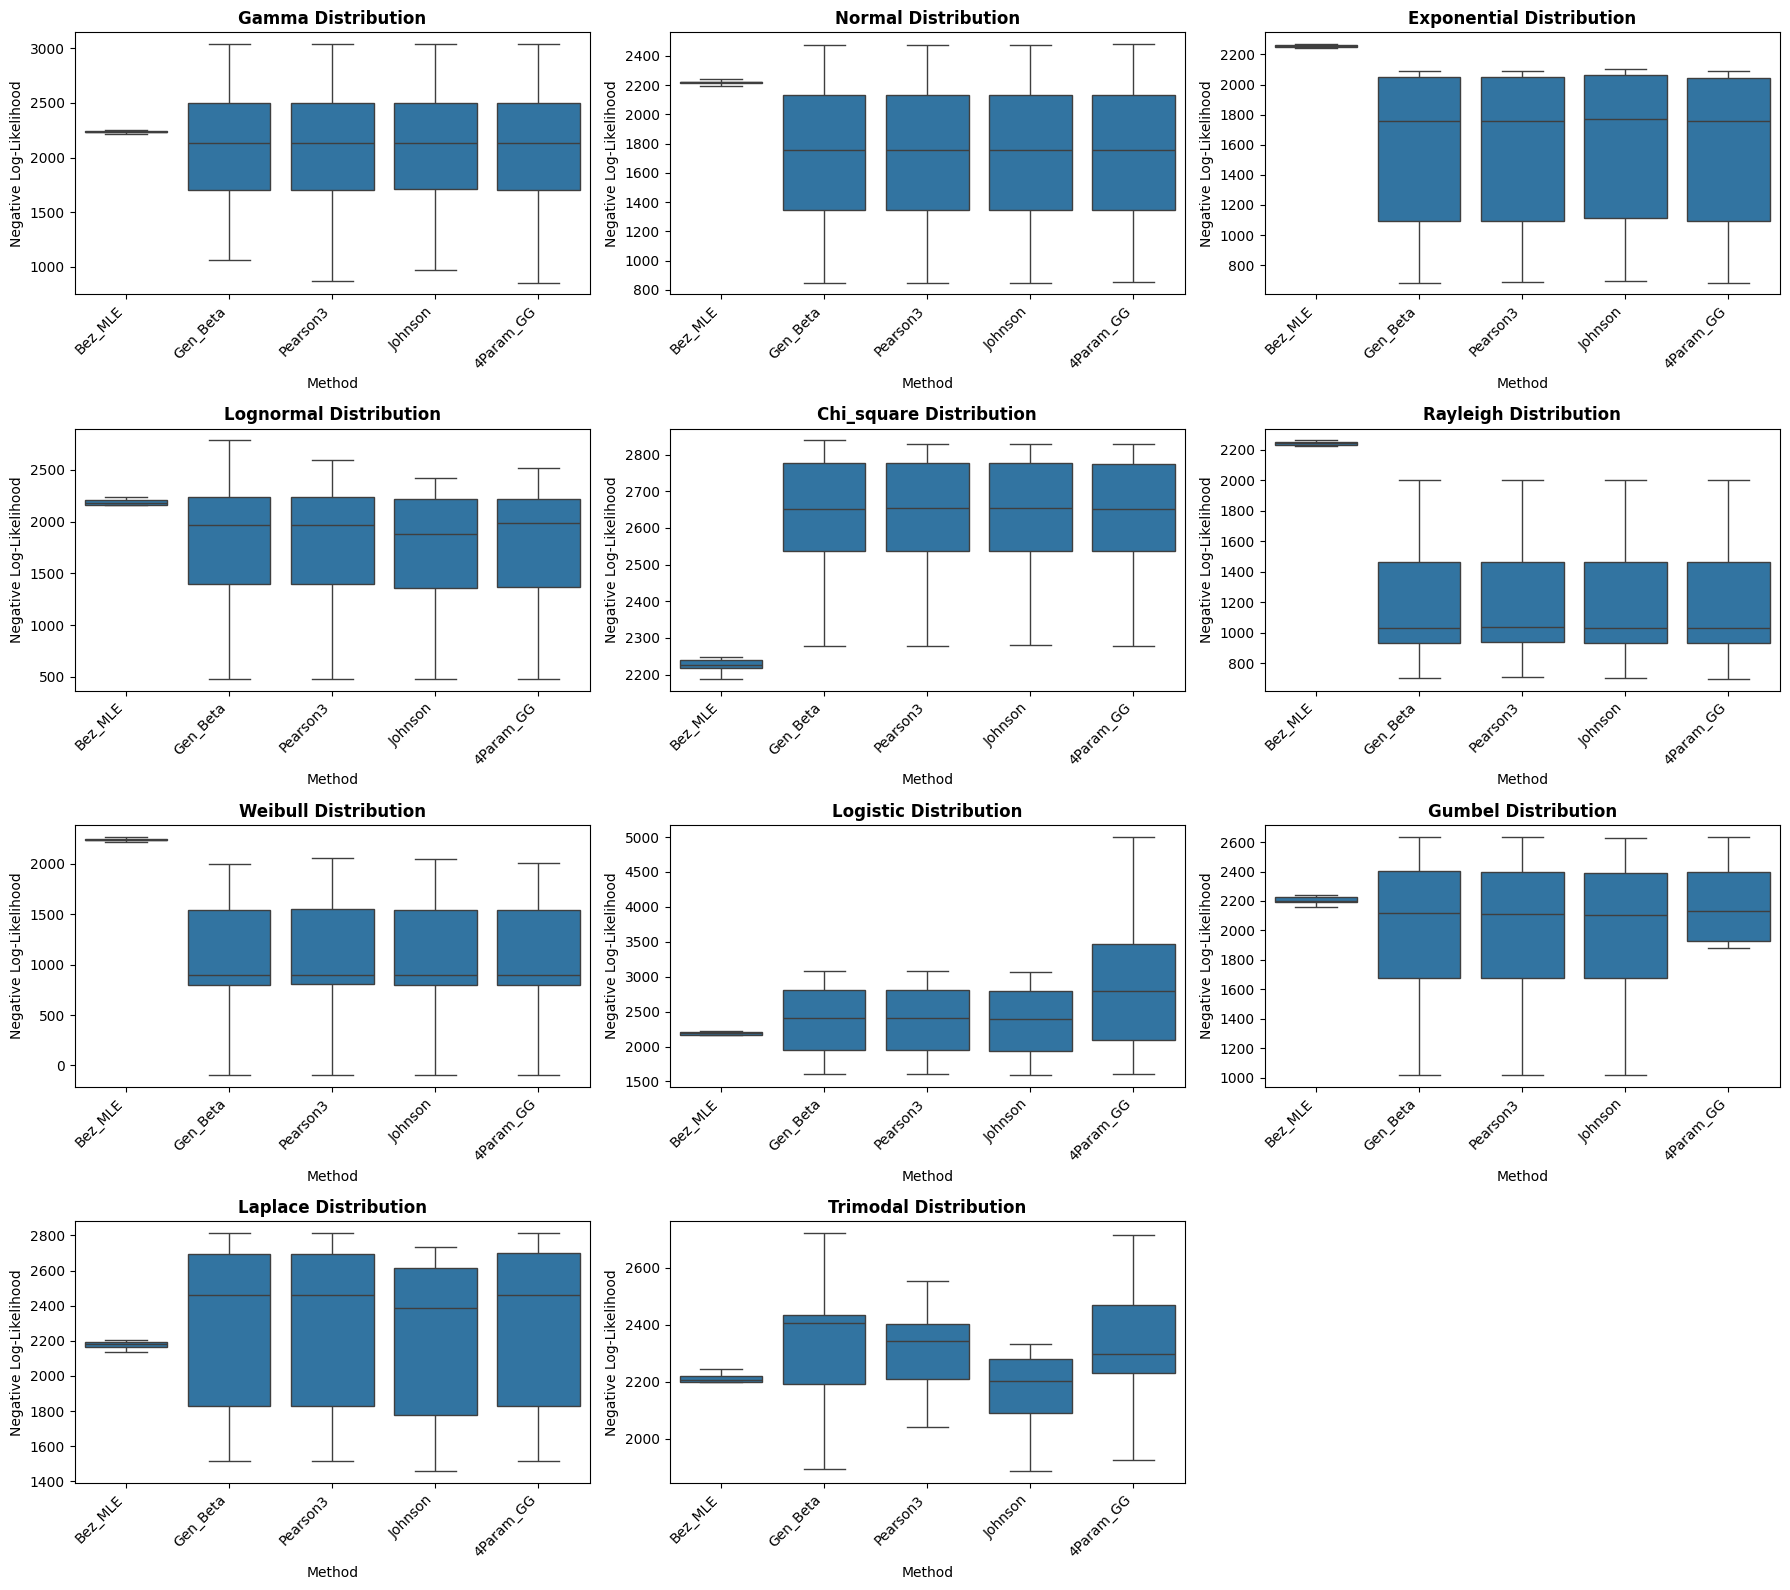

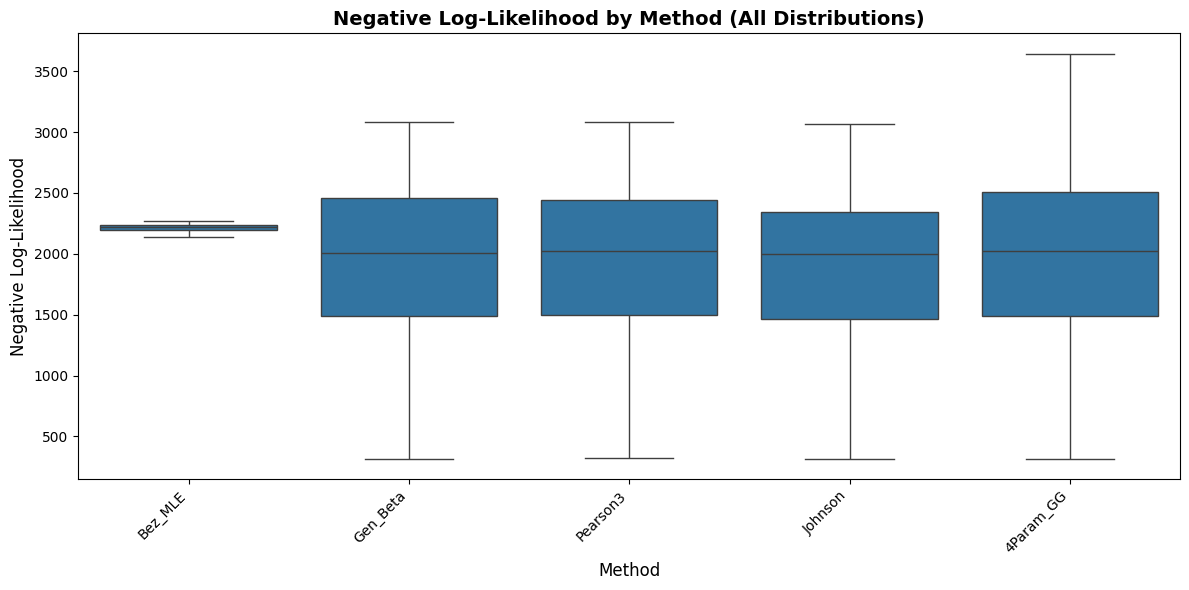

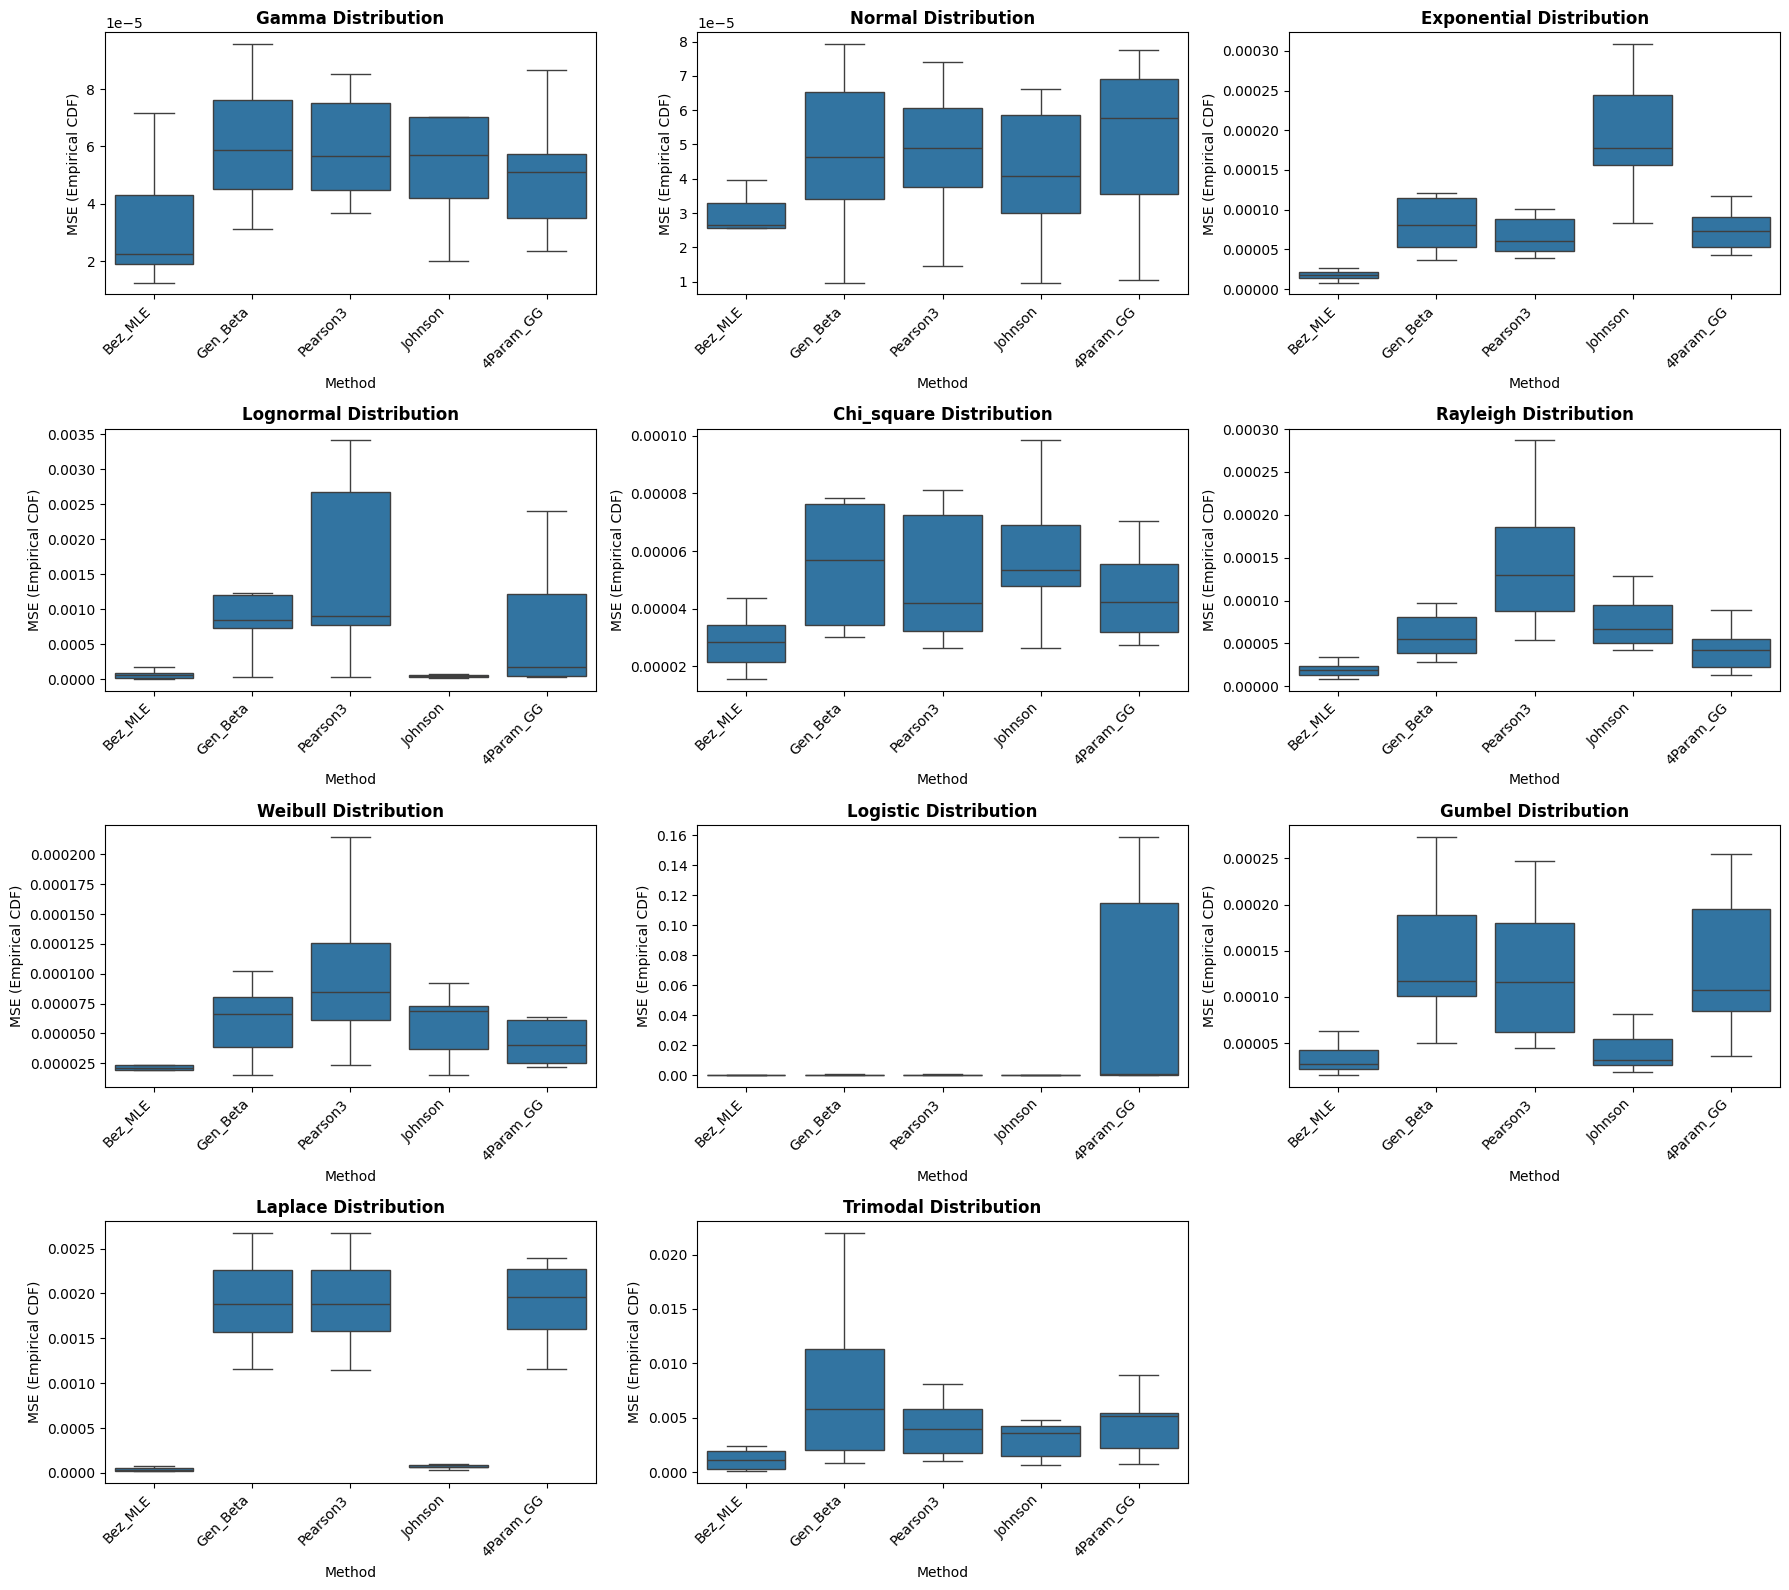

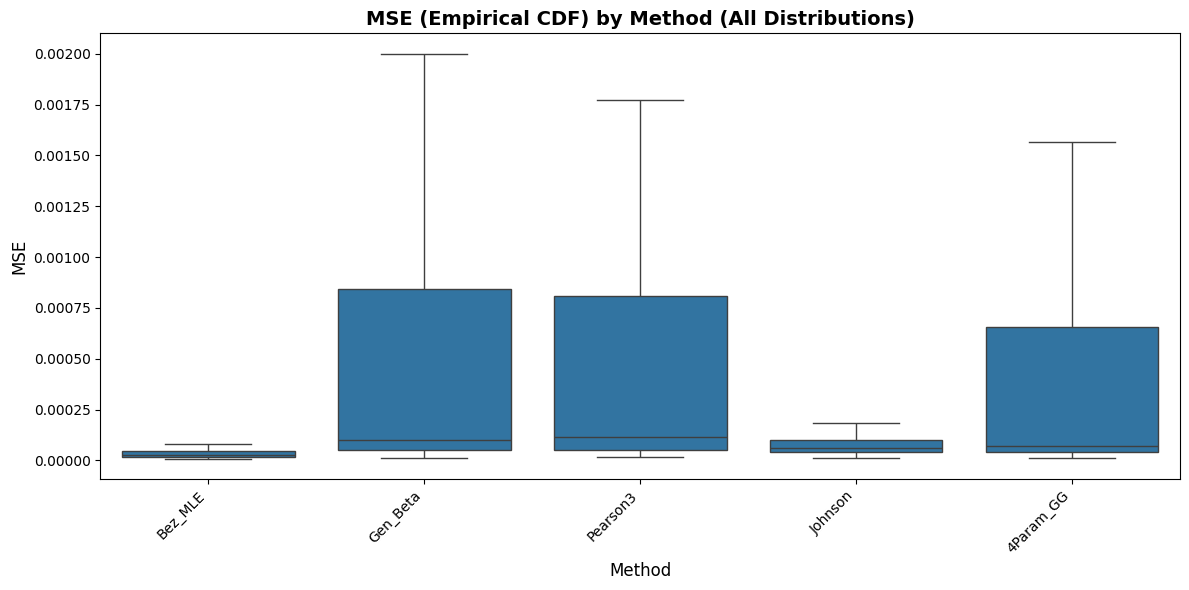

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Read the results
df = pd.read_csv('benchmark_results.csv')

# ========== NEGATIVE LOG-LIKELIHOOD PLOTS ==========
# Create box plots for each distribution
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, dist in enumerate(df['Dist'].unique()):
    dist_data = df[df['Dist'] == dist]
    ax = axes[idx]
    
    sns.boxplot(data=dist_data, x='Method', y='NegLogLik', ax=ax, showfliers=False)
    ax.set_title(f'{dist.capitalize()} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Method', fontsize=10)
    ax.set_ylabel('Negative Log-Likelihood', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Remove extra subplots if any
for idx in range(len(df['Dist'].unique()), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('benchmark_boxplot_nll_by_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a single box plot comparing all methods across all distributions
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Method', y='NegLogLik', showfliers=False)
plt.title('Negative Log-Likelihood by Method (All Distributions)', fontsize=14, fontweight='bold')
plt.xlabel('Method', fontsize=12)
plt.ylabel('Negative Log-Likelihood', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('benchmark_boxplot_nll_overall.png', dpi=300, bbox_inches='tight')
plt.show()

# ========== MSE PLOTS ==========
# Create box plots for each distribution
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()

for idx, dist in enumerate(df['Dist'].unique()):
    dist_data = df[df['Dist'] == dist]
    ax = axes[idx]
    
    sns.boxplot(data=dist_data, x='Method', y='MSE', ax=ax, showfliers=False)
    ax.set_title(f'{dist.capitalize()} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel('Method', fontsize=10)
    ax.set_ylabel('MSE (Empirical CDF)', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Remove extra subplots if any
for idx in range(len(df['Dist'].unique()), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('benchmark_boxplot_mse_by_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a single box plot comparing all methods across all distributions
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Method', y='MSE', showfliers=False)
plt.title('MSE (Empirical CDF) by Method (All Distributions)', fontsize=14, fontweight='bold')
plt.xlabel('Method', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('benchmark_boxplot_mse_overall.png', dpi=300, bbox_inches='tight')
plt.show()
